# Fourier Amplitude Spectra (FAS)

## License Information

This file is part of _hvsrpy_, a Python package for horizontal-to-vertical spectral ratio processing.

    Copyright (C) 2019-2026 Joseph P. Vantassel (joseph.p.vantassel@gmail.com)

    This program is free software: you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation, either version 3 of the License, or
    (at your option) any later version.

    This program is distributed in the hope that it will be useful,
    but WITHOUT ANY WARRANTY; without even the implied warranty of
    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
    GNU General Public License for more details.

    You should have received a copy of the GNU General Public License
    along with this program.  If not, see <https: //www.gnu.org/licenses/>.
    
## About _hvsrpy_

_hvsrpy_ is an open-source Python package for performing horizontal-to-vertical spectral ratio (HVSR) processing of microtremor and earthquake recordings. _hvsrpy_ was developed by [Joseph P. Vantassel](https://www.jpvantassel.com/) with contributions from Dana M. Brannon under the supervision of Professor Brady R. Cox at The University of Texas at Austin. _hvsrpy_ continues to be developed and maintained by [Joseph P. Vantassel and his research group at Virginia Tech](https://geoimaging-research.org/).

## Citation

If you use _hvsrpy_ in your research or consulting, we ask you please cite the following:

> Vantassel, J.P. (2025). "_hvsrpy_: An Open‐Source Python Package for Microtremor
> and Earthquake Horizontal‐to‐Vertical Spectral Ratio Processing". Seismological
> Research Letters. 96 (4): 2671–2682,
> [https://doi.org/10.1785/0220240395](https://doi.org/10.1785/0220240395)

> Joseph Vantassel. (2020). jpvantassel/hvsrpy: latest (Concept). Zenodo.
> [http://doi.org/10.5281/zenodo.3666956](http://doi.org/10.5281/zenodo.3666956)

_For software, version specific citations should be preferred to
general concept citations. To generate a version specific citation
for `hvsrpy`, please use the citation tool on the `hvsrpy`
[archive](http://doi.org/10.5281/zenodo.3666956)._

## About this notebook

This notebook illustrates how _hvsrpy_ can be used for computing the Fourier amplitude spectra (FAS).

## Getting Started

1. Install _hvsrpy_, with `pip install hvsrpy`. More information on _pip_ can be found [here](https://jpvantassel.github.io/python3-course/#/intro/pip). __(~3 minutes)__
2. Try analyzing the provided example. __(~10 minutes)__
3. Try your own files by changing the file names and insrument details below. __(~15 minutes)__

Happy Processing!

In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import hvsrpy
from hvsrpy.instrument_response import InstrumentTransferFunction

plt.style.use(hvsrpy.HVSRPY_MPL_STYLE)

## Instrument Details

In [2]:
# SmartSolo | IGU-16HR 3C
poles = [
 (-22.211059+22.211059j),
 (-22.211059-22.211059j),
]
zeros= [
    (0+0j),
    (0+0j),
]
instrument_sensitivity = 2.576980e8
normalization_factor = 1
itf = InstrumentTransferFunction(poles=poles,
                                 zeros=zeros,
                                 instrument_sensitivity=instrument_sensitivity, 
                                 normalization_factor=normalization_factor)

## Input Data

In [3]:
fnames = [
    [f"./data/453016990.0001.{comp}.miniseed" for comp in "NEZ"]
]

print(f"Number of recordings: {len(fnames)}")
for fname_set in fnames:
    for file in fname_set:
        if not pathlib.Path(file).exists():
            raise FileNotFoundError(f"file {file} not found; check spelling.")
print("All files exist.")

Number of recordings: 1
All files exist.


## Power Spectral Density Preprocessing Settings

In [4]:
preprocessing_settings = hvsrpy.settings.FasPreProcessingSettings()
preprocessing_settings.orient_to_degrees_from_north = 0.0
preprocessing_settings.filter_corner_frequencies_in_hz=(0.005, None)
preprocessing_settings.window_length_in_seconds = 60
preprocessing_settings.detrend = "linear"
preprocessing_settings.window_type_and_width = ('tukey', 0.1)
preprocessing_settings.instrument_transfer_function=itf
preprocessing_settings.differentiate=True

print("Preprocessing Summary")
print("-"*60)
preprocessing_settings.psummary()

Preprocessing Summary
------------------------------------------------------------
hvsrpy_version                           : 2.2.0rc1
orient_to_degrees_from_north             : 0.0
filter_corner_frequencies_in_hz          : (0.005, None)
window_length_in_seconds                 : 60
detrend                                  : linear
window_type_and_width                    : ('tukey', 0.1)
fft_settings                             : None
instrument_transfer_function             : InstrumentTransferFunction at 139690232868320
differentiate                            : True
preprocessing_method                     : fas


## Power Spectral Density Processing Settings

In [5]:
processing_settings = hvsrpy.settings.FasProcessingSettings()
processing_settings.window_type_and_width=('tukey', 0.1)
processing_settings.smoothing=dict(operator="konno_and_ohmachi",
                                   bandwidth=40,
                                   center_frequencies_in_hz=np.geomspace(0.1, 100, 200))

print("Processing Summary")
print("-"*60)
processing_settings.psummary()

Processing Summary
------------------------------------------------------------
hvsrpy_version                           : 2.2.0rc1
window_type_and_width                    : ('tukey', 0.1)
smoothing                                :
     operator                            : konno_and_ohmachi
     bandwidth                           : 40
     center_frequencies_in_hz            : [0.1, 0.103532184329 ... 832241158699, 100.0]
fft_settings                             : None
handle_dissimilar_time_steps_by          : keeping_majority_time_step
processing_method                        : fas


## Calculate
---

In [6]:
srecords = hvsrpy.read(fnames)
srecords = hvsrpy.preprocess(srecords, preprocessing_settings)
fass = hvsrpy.process(srecords, processing_settings)

## Summarize FAS Results - Mean Curve (Log-Scale)

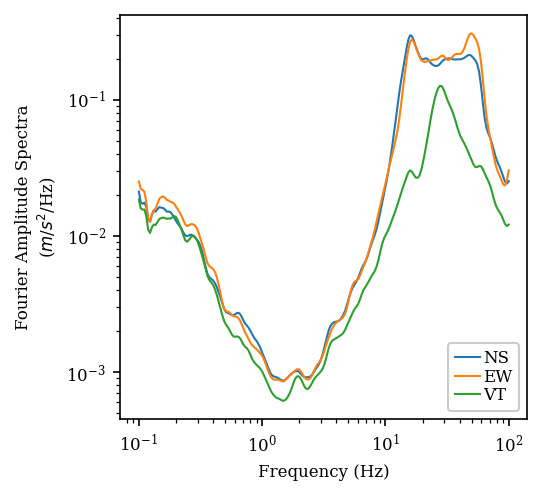

In [7]:
fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=150)

for component, fas in fass.items():
    mean_curve = np.exp(np.mean(np.log(fas.amplitude), axis=0))
    ax.plot(fas.frequency, mean_curve, label=f"{component.upper()}", lw=1)

ax.legend(loc="upper right")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Fourier Amplitude Spectra\n" +r"($m$/$s^2$/Hz)")
# TODO(jpv): Check units
ax.legend(loc="lower right")
plt.show()

## Summarize FAS Results - All Curve (Log-Scale)

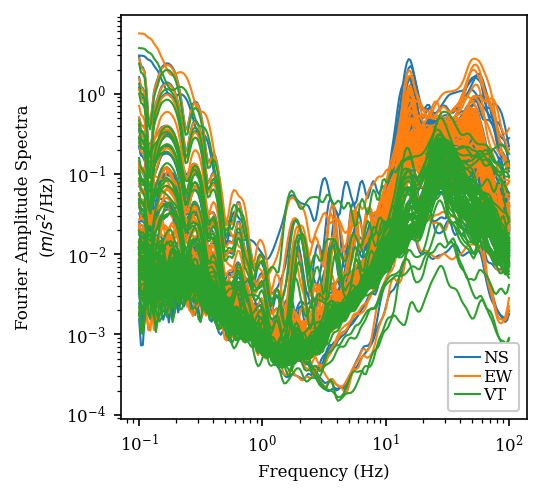

In [8]:
fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=150)

colors = ["tab:blue", "tab:orange", "tab:green"]
for (component, fas), color in zip(fass.items(), colors):
    label = label=f"{component.upper()}"
    for amplitude in fas.amplitude:
        ax.plot(fas.frequency, amplitude, label=label, color=color, lw=1)
        label = None

ax.legend(loc="upper right")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Fourier Amplitude Spectra\n" +r"($m$/$s^2$/Hz)")
# TODO(jpv): Check units
ax.legend(loc="lower right")
plt.show()